In [1]:
from google.colab import files
uploaded = files.upload()

Saving dark_patterns_clean.csv to dark_patterns_clean (1).csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

df = pd.read_csv('dark_patterns_clean.csv')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (213, 20)
Columns: ['age_group', 'gender', 'income_level', 'orders_per_week', 'app_used', 'p1_urgency', 'p2_hidden_charges', 'p3_preadded', 'p4_cancel_diff', 'p5_confirmshaming', 'p6_fake_delivery', 'intended_budget', 'actual_spend', 'unplanned_items', 'unplanned_subscription', 'dark_patterns_identified', 'protection_intent', 'belief_in_intent', 'manipulation_score', 'extra_spend']


In [3]:
if df['orders_per_week'].dtype == 'object':
    orders_map = {'1-2 times': 1.5, '3-5 times': 4, '6 or more times': 6}
    df['orders_per_week_num'] = df['orders_per_week'].map(orders_map)
else:
    df['orders_per_week_num'] = df['orders_per_week']

print("orders_per_week_num sample:")
print(df['orders_per_week_num'].value_counts())

orders_per_week_num sample:
orders_per_week_num
1.5    178
4.0     33
6.0      2
Name: count, dtype: int64


In [4]:
df = df.copy()
df['awareness_group'] = pd.cut(
    df['protection_intent'],
    bins=[0, 2, 3, 5],
    labels=['Low', 'Medium', 'High']
)
print("Awareness group counts:")
print(df['awareness_group'].value_counts())

Awareness group counts:
awareness_group
High      86
Medium    85
Low       42
Name: count, dtype: int64


In [5]:
print("manipulation_score — min:", df['manipulation_score'].min(),
      "max:", df['manipulation_score'].max(),
      "mean:", round(df['manipulation_score'].mean(), 2))

print("extra_spend — mean:", round(df['extra_spend'].mean(), 2))
print("unplanned_items — value counts:")
print(df['unplanned_items'].value_counts())

manipulation_score — min: 0 max: 37 mean: 18.73
extra_spend — mean: 169.07
unplanned_items — value counts:
unplanned_items
0    113
1    100
Name: count, dtype: int64


In [6]:
print("=== MANIPULATION SCORE ===")
print(df['manipulation_score'].describe().round(2))

print("\n=== EXTRA SPEND (Rs) ===")
print(df['extra_spend'].describe().round(2))

print("\n=== APP COMPARISON ===")
print(df.groupby('app_used')[['manipulation_score','extra_spend']].mean().round(2))

=== MANIPULATION SCORE ===
count    213.00
mean      18.73
std        6.57
min        0.00
25%       15.00
50%       20.00
75%       22.00
max       37.00
Name: manipulation_score, dtype: float64

=== EXTRA SPEND (Rs) ===
count     213.00
mean      169.07
std       274.55
min      -740.00
25%        50.00
50%       160.00
75%       290.00
max      1300.00
Name: extra_spend, dtype: float64

=== APP COMPARISON ===
                  manipulation_score  extra_spend
app_used                                         
Both Equally                   19.85       182.85
Call restaurant                12.00       -50.00
Swiggy                         20.22       177.94
Zomato                         17.55       160.05


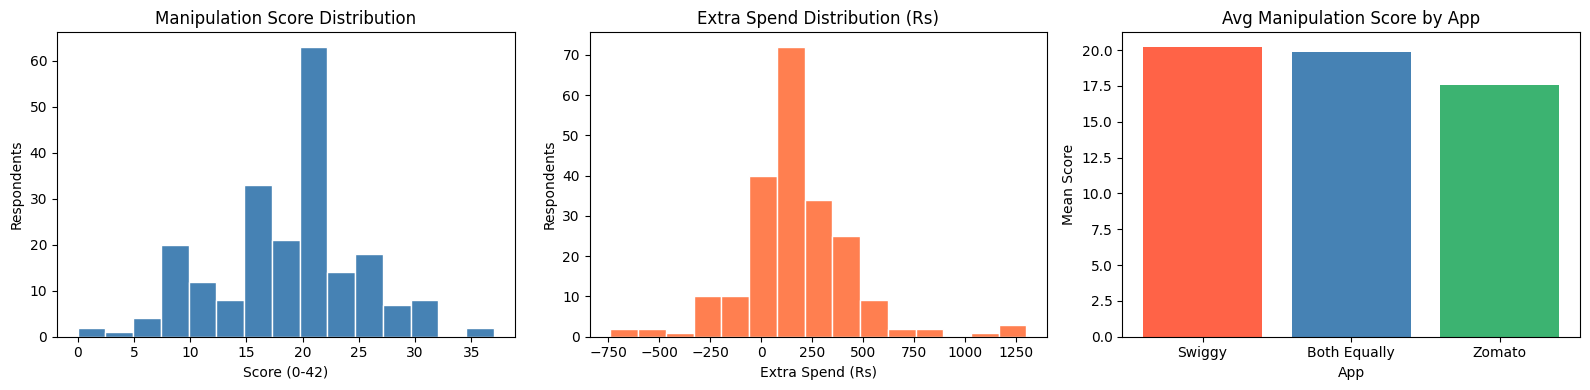

Saved ✅


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['manipulation_score'], bins=15, color='steelblue', edgecolor='white')
axes[0].set_title('Manipulation Score Distribution')
axes[0].set_xlabel('Score (0-42)')
axes[0].set_ylabel('Respondents')

axes[1].hist(df['extra_spend'].dropna(), bins=15, color='coral', edgecolor='white')
axes[1].set_title('Extra Spend Distribution (Rs)')
axes[1].set_xlabel('Extra Spend (Rs)')
axes[1].set_ylabel('Respondents')

app_data = df[df['app_used'].isin(['Zomato','Swiggy','Both Equally'])]
app_scores = app_data.groupby('app_used')['manipulation_score'].mean().sort_values(ascending=False)
axes[2].bar(app_scores.index, app_scores.values,
            color=['tomato','steelblue','mediumseagreen'])
axes[2].set_title('Avg Manipulation Score by App')
axes[2].set_xlabel('App')
axes[2].set_ylabel('Mean Score')

plt.tight_layout()
plt.savefig('descriptive_stats.png', dpi=150)
plt.show()
print("Saved ✅")

In [8]:
from scipy.stats import pointbiserialr

clean = df[['manipulation_score','unplanned_items']].dropna()

r_pb, p_pb = pointbiserialr(
    clean['unplanned_items'],
    clean['manipulation_score']
)

print("=== POINT-BISERIAL CORRELATION ===")
print(f"r = {round(r_pb, 4)}")
print(f"p = {round(p_pb, 6)}")

if p_pb < 0.05:
    print("\nResult is STATISTICALLY SIGNIFICANT (p < 0.05)")
    print("We REJECT H0 — manipulation score IS related to unplanned purchases")
else:
    print("\nResult is NOT significant (p > 0.05)")

if abs(r_pb) > 0.5:
    print(f"Strong correlation (r = {round(r_pb, 4)})")
elif abs(r_pb) > 0.3:
    print(f"Moderate correlation (r = {round(r_pb, 4)})")
else:
    print(f"Weak correlation (r = {round(r_pb, 4)})")

print("\nNote: Point-Biserial is the correct test when one variable")
print("is continuous and the other is binary (0/1).")
print("Mathematically equivalent to Pearson but correctly specified.")

=== POINT-BISERIAL CORRELATION ===
r = 0.3787
p = 0.0

Result is STATISTICALLY SIGNIFICANT (p < 0.05)
We REJECT H0 — manipulation score IS related to unplanned purchases
Moderate correlation (r = 0.3787)

Note: Point-Biserial is the correct test when one variable
is continuous and the other is binary (0/1).
Mathematically equivalent to Pearson but correctly specified.


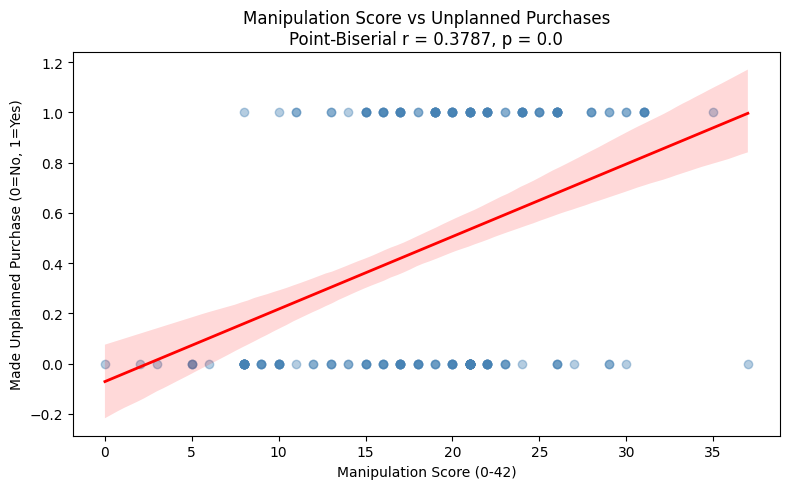

Saved ✅


In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(
    x='manipulation_score', y='unplanned_items',
    data=df,
    scatter_kws={'alpha': 0.4, 'color': 'steelblue'},
    line_kws={'color': 'red', 'linewidth': 2}
)
ax.set_title(f'Manipulation Score vs Unplanned Purchases\nPoint-Biserial r = {round(r_pb, 4)}, p = {round(p_pb, 6)}')
ax.set_xlabel('Manipulation Score (0-42)')
ax.set_ylabel('Made Unplanned Purchase (0=No, 1=Yes)')
plt.tight_layout()
plt.savefig('point_biserial.png', dpi=150)
plt.show()
print("Saved ✅")

In [10]:
df['pct_overspend'] = (
    (df['actual_spend'] - df['intended_budget']) / df['intended_budget'] * 100
)

print("=== PERCENTAGE OVERSPEND ===")
print(df['pct_overspend'].describe().round(2))

print(f"\nMean % overspend: {round(df['pct_overspend'].mean(), 2)}%")
print(f"Median % overspend: {round(df['pct_overspend'].median(), 2)}%")
print(f"People who overspent: {(df['pct_overspend'] > 0).sum()} out of {df['pct_overspend'].notna().sum()}")

=== PERCENTAGE OVERSPEND ===
count    213.00
mean      68.59
std       86.85
min      -61.67
25%       12.50
50%       41.25
75%      113.33
max      366.67
Name: pct_overspend, dtype: float64

Mean % overspend: 68.59%
Median % overspend: 41.25%
People who overspent: 167 out of 213


In [11]:
clean2 = df[['manipulation_score','pct_overspend']].dropna()

r_pct, p_pct = pearsonr(clean2['manipulation_score'], clean2['pct_overspend'])

print("=== PEARSON: manipulation_score vs pct_overspend ===")
print(f"r = {round(r_pct, 4)}")
print(f"p = {round(p_pct, 6)}")

if p_pct < 0.05:
    print("\nSignificant — manipulation score predicts % overspend")
else:
    print("\nNot significant")

print("\nFor comparison:")
r_raw, p_raw = pearsonr(
    df['manipulation_score'].dropna(),
    df['extra_spend'].dropna()
)
print(f"manipulation_score vs raw extra_spend: r={round(r_raw,4)}, p={round(p_raw,4)}")
print(f"manipulation_score vs pct_overspend:   r={round(r_pct,4)}, p={round(p_pct,4)}")
print("\nPercentage overspend controls for order size — a fairer comparison.")

=== PEARSON: manipulation_score vs pct_overspend ===
r = 0.2154
p = 0.001568

Significant — manipulation score predicts % overspend

For comparison:
manipulation_score vs raw extra_spend: r=0.0977, p=0.1555
manipulation_score vs pct_overspend:   r=0.2154, p=0.0016

Percentage overspend controls for order size — a fairer comparison.


In [12]:
from scipy.stats import chi2_contingency

ct = pd.crosstab(df['awareness_group'], df['income_level'])
print("=== CONTINGENCY TABLE ===")
print(ct)

chi2, p, dof, expected = chi2_contingency(ct)

print(f"\n=== CHI-SQUARE RESULT ===")
print(f"Chi2 = {round(chi2, 4)}")
print(f"Degrees of freedom = {dof}")
print(f"p = {round(p, 6)}")

if p < 0.05:
    print("\nSignificant — awareness IS related to income level")
else:
    print("\nNot significant")

=== CONTINGENCY TABLE ===
income_level      1   2   3   4
awareness_group                
Low              18   8   7   9
Medium           33  10   5  37
High             21  15  11  39

=== CHI-SQUARE RESULT ===
Chi2 = 13.2783
Degrees of freedom = 6
p = 0.038824

Significant — awareness IS related to income level


In [13]:
from scipy.stats import ttest_ind

zomato = df[df['app_used'] == 'Zomato']['manipulation_score'].dropna()
swiggy = df[df['app_used'] == 'Swiggy']['manipulation_score'].dropna()

print("=== ZOMATO vs SWIGGY — INDEPENDENT t-TEST ===")
print(f"Zomato — mean: {round(zomato.mean(), 2)},  n = {len(zomato)}")
print(f"Swiggy — mean: {round(swiggy.mean(), 2)},  n = {len(swiggy)}")
print(f"Difference: {round(zomato.mean() - swiggy.mean(), 2)} points")

t_stat, p_val = ttest_ind(zomato, swiggy)

print(f"\nt-statistic = {round(t_stat, 4)}")
print(f"p-value     = {round(p_val, 4)}")

if p_val < 0.05:
    higher = 'Zomato' if zomato.mean() > swiggy.mean() else 'Swiggy'
    print(f"\nSignificant — {higher} users have a significantly higher manipulation score")
else:
    print("\nNot significant — no meaningful difference between apps")

=== ZOMATO vs SWIGGY — INDEPENDENT t-TEST ===
Zomato — mean: 17.55,  n = 108
Swiggy — mean: 20.22,  n = 49
Difference: -2.68 points

t-statistic = -2.2532
p-value     = 0.0256

Significant — Swiggy users have a significantly higher manipulation score


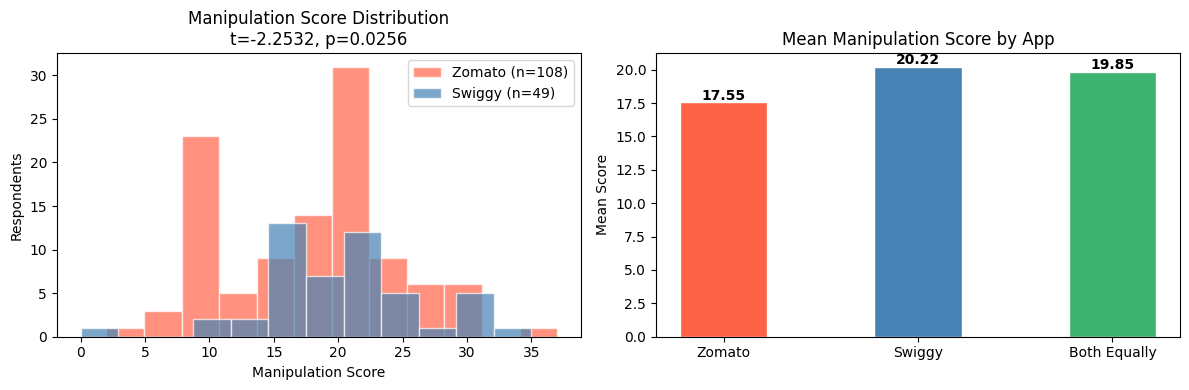

Saved ✅


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(zomato, bins=12, alpha=0.7, color='tomato',
             edgecolor='white', label=f'Zomato (n={len(zomato)})')
axes[0].hist(swiggy, bins=12, alpha=0.7, color='steelblue',
             edgecolor='white', label=f'Swiggy (n={len(swiggy)})')
axes[0].set_title(f'Manipulation Score Distribution\nt={round(t_stat,4)}, p={round(p_val,4)}')
axes[0].set_xlabel('Manipulation Score')
axes[0].set_ylabel('Respondents')
axes[0].legend()

apps = ['Zomato', 'Swiggy', 'Both Equally']
means = [df[df['app_used']==a]['manipulation_score'].mean() for a in apps]
colors = ['tomato', 'steelblue', 'mediumseagreen']
bars = axes[1].bar(apps, means, color=colors, edgecolor='white', width=0.45)
for bar, val in zip(bars, means):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.2,
                 str(round(val, 2)),
                 ha='center', fontweight='bold')
axes[1].set_title('Mean Manipulation Score by App')
axes[1].set_ylabel('Mean Score')

plt.tight_layout()
plt.savefig('zomato_vs_swiggy.png', dpi=150)
plt.show()
print("Saved ✅")

In [15]:
from scipy.stats import f_oneway

zomato_spend = df[df['app_used'] == 'Zomato']['extra_spend'].dropna()
swiggy_spend = df[df['app_used'] == 'Swiggy']['extra_spend'].dropna()
both_spend   = df[df['app_used'] == 'Both Equally']['extra_spend'].dropna()

print("=== ANOVA — EXTRA SPEND ACROSS APP GROUPS ===")
print(f"Zomato      — mean: Rs{round(zomato_spend.mean(),2)},  n={len(zomato_spend)}")
print(f"Swiggy      — mean: Rs{round(swiggy_spend.mean(),2)},  n={len(swiggy_spend)}")
print(f"Both Equally — mean: Rs{round(both_spend.mean(),2)},  n={len(both_spend)}")

F, p = f_oneway(zomato_spend, swiggy_spend, both_spend)

print(f"\nF-statistic = {round(F, 4)}")
print(f"p-value     = {round(p, 4)}")

if p < 0.05:
    print("\nSignificant — extra spending DOES differ across app groups")
else:
    print("\nNot significant — no meaningful spending difference across apps")

=== ANOVA — EXTRA SPEND ACROSS APP GROUPS ===
Zomato      — mean: Rs160.05,  n=108
Swiggy      — mean: Rs177.94,  n=49
Both Equally — mean: Rs182.85,  n=55

F-statistic = 0.1503
p-value     = 0.8606

Not significant — no meaningful spending difference across apps


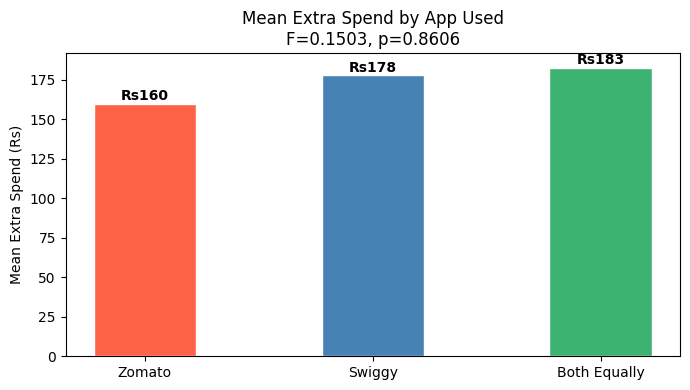

Saved ✅


In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
groups = ['Zomato', 'Swiggy', 'Both Equally']
means_spend = [zomato_spend.mean(), swiggy_spend.mean(), both_spend.mean()]
colors = ['tomato', 'steelblue', 'mediumseagreen']

bars = ax.bar(groups, means_spend, color=colors, edgecolor='white', width=0.45)
for bar, val in zip(bars, means_spend):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+2,
            f'Rs{round(val)}',
            ha='center', fontweight='bold')

ax.set_title(f'Mean Extra Spend by App Used\nF={round(F,4)}, p={round(p,4)}')
ax.set_ylabel('Mean Extra Spend (Rs)')
plt.tight_layout()
plt.savefig('anova_app_used.png', dpi=150)
plt.show()
print("Saved ✅")

=== LOGISTIC REGRESSION (original) ===
Accuracy: 60.47%
                    precision    recall  f1-score   support

      No Unplanned       0.69      0.48      0.56        23
Unplanned Purchase       0.56      0.75      0.64        20

          accuracy                           0.60        43
         macro avg       0.62      0.61      0.60        43
      weighted avg       0.63      0.60      0.60        43



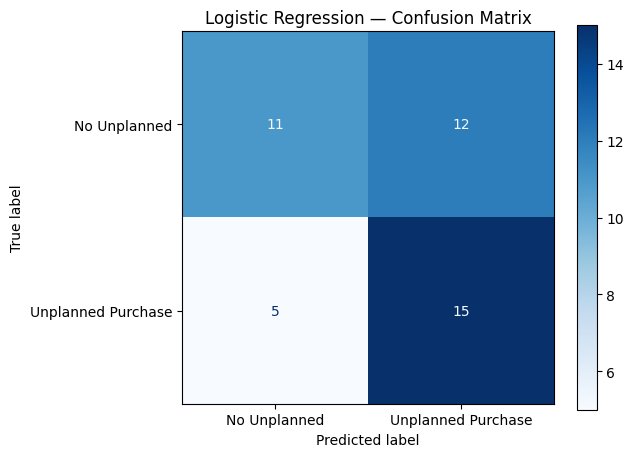

Saved ✅


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

feature_cols = ['manipulation_score','orders_per_week_num',
                'income_level','protection_intent']

clean3 = df[feature_cols + ['unplanned_items']].dropna()
X = clean3[feature_cols]
y = clean3['unplanned_items']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

log_model = LogisticRegression(max_iter=1000).fit(X_train, y_train)
y_pred = log_model.predict(X_test)

print("=== LOGISTIC REGRESSION (original) ===")
print(f"Accuracy: {round(log_model.score(X_test, y_test)*100, 2)}%")
print(classification_report(y_test, y_pred,
      target_names=['No Unplanned','Unplanned Purchase']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
       display_labels=['No Unplanned','Unplanned Purchase'])
disp.plot(cmap='Blues')
plt.title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Saved ✅")

In [18]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(log_model, X, y, cv=cv, scoring='accuracy')

print("=== 5-FOLD CROSS-VALIDATION ===")
print("Accuracy per fold:")
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {round(s*100, 2)}%")

print(f"\nMean accuracy:  {round(cv_scores.mean()*100, 2)}%")
print(f"Std deviation:  ± {round(cv_scores.std()*100, 2)}%")
print(f"Min: {round(cv_scores.min()*100, 2)}%   Max: {round(cv_scores.max()*100, 2)}%")
print(f"\nFinal report accuracy: {round(cv_scores.mean()*100, 2)}% ± {round(cv_scores.std()*100, 2)}%")
print("\nThis is more reliable than a single 80/20 split because it")
print("trains and tests on 5 different data splits and averages them.")

=== 5-FOLD CROSS-VALIDATION ===
Accuracy per fold:
  Fold 1: 53.49%
  Fold 2: 65.12%
  Fold 3: 67.44%
  Fold 4: 54.76%
  Fold 5: 66.67%

Mean accuracy:  61.5%
Std deviation:  ± 6.08%
Min: 53.49%   Max: 67.44%

Final report accuracy: 61.5% ± 6.08%

This is more reliable than a single 80/20 split because it
trains and tests on 5 different data splits and averages them.


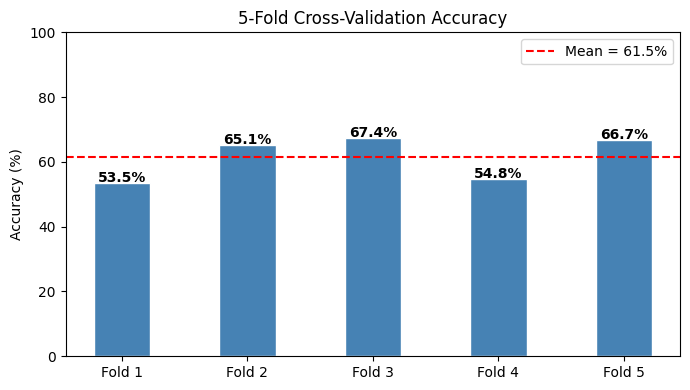

Saved ✅


In [19]:
fig, ax = plt.subplots(figsize=(7, 4))
folds = [f'Fold {i}' for i in range(1, 6)]
bars = ax.bar(folds, cv_scores*100,
              color='steelblue', edgecolor='white', width=0.45)
ax.axhline(y=cv_scores.mean()*100, color='red',
           linestyle='--', linewidth=1.5,
           label=f'Mean = {round(cv_scores.mean()*100,2)}%')
for bar, val in zip(bars, cv_scores):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.3,
            f'{round(val*100,1)}%',
            ha='center', fontweight='bold')
ax.set_title('5-Fold Cross-Validation Accuracy')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 100)
ax.legend()
plt.tight_layout()
plt.savefig('cross_validation.png', dpi=150)
plt.show()
print("Saved ✅")

In [21]:
import pickle
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_features = df[['manipulation_score','protection_intent','unplanned_items']].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_features)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_scaled)

df.loc[cluster_features.index, 'cluster'] = kmeans.labels_

print("=== CLUSTER PROFILES ===")
print(df.groupby('cluster')[['manipulation_score','protection_intent',
                              'unplanned_items','extra_spend']].mean().round(2))

with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

with open('kmeans_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("\nkmeans_model.pkl saved ✅")
print("kmeans_scaler.pkl saved ✅")

=== CLUSTER PROFILES ===
         manipulation_score  protection_intent  unplanned_items  extra_spend
cluster                                                                     
0.0                   20.17               3.86             0.00       121.44
1.0                   21.62               3.29             1.00       220.79
2.0                   10.20               2.53             0.04       130.51

kmeans_model.pkl saved ✅
kmeans_scaler.pkl saved ✅


In [22]:
import pickle

with open('logistic_model.pkl', 'wb') as f:
    pickle.dump(log_model, f)

df.to_csv('dark_patterns_clean.csv', index=False)

print("Files saved ✅")
print("\nDownload from Files panel on the left:")
print("  1. logistic_model.pkl  (updated model)")
print("  2. dark_patterns_clean.csv  (now has pct_overspend column)")
print("\nReplace these in your streamlit ssdi project folder")
print("before running the Streamlit app again.")

Files saved ✅

Download from Files panel on the left:
  1. logistic_model.pkl  (updated model)
  2. dark_patterns_clean.csv  (now has pct_overspend column)

Replace these in your streamlit ssdi project folder
before running the Streamlit app again.


In [23]:
print("=" * 55)
print("COMPLETE RESULTS SUMMARY")
print("=" * 55)

print(f"\nDataset: {len(df)} rows, {len(df.columns)} columns")
print(f"Avg manipulation score: {round(df['manipulation_score'].mean(),2)} / 42")
print(f"Avg extra spend:        Rs{round(df['extra_spend'].mean(),2)}")
print(f"Avg % overspend:        {round(df['pct_overspend'].mean(),2)}%")

print("\n--- CORRELATIONS ---")
print(f"Point-Biserial r (manip vs unplanned): {round(r_pb,4)}, p={round(p_pb,6)}")
print(f"Pearson r (manip vs pct_overspend):     {round(r_pct,4)}, p={round(p_pct,4)}")
print(f"Pearson r (manip vs raw extra_spend):   {round(r_raw,4)}, p={round(p_raw,4)}")

print("\n--- CHI-SQUARE ---")
print(f"Chi2={round(chi2,4)}, dof={dof}, p={round(p,4)}")

print("\n--- t-TEST (Zomato vs Swiggy) ---")
print(f"Zomato mean: {round(zomato.mean(),2)}, Swiggy mean: {round(swiggy.mean(),2)}")
print(f"t={round(t_stat,4)}, p={round(p_val,4)}")

print("\n--- ANOVA (by app) ---")
print(f"F={round(F,4)}, p={round(p,4)}")

print("\n--- LOGISTIC REGRESSION ---")
print(f"Single split accuracy: {round(log_model.score(X_test,y_test)*100,2)}%")
print(f"5-fold CV accuracy:    {round(cv_scores.mean()*100,2)}% ± {round(cv_scores.std()*100,2)}%")
print("=" * 55)

COMPLETE RESULTS SUMMARY

Dataset: 213 rows, 24 columns
Avg manipulation score: 18.73 / 42
Avg extra spend:        Rs169.07
Avg % overspend:        68.59%

--- CORRELATIONS ---
Point-Biserial r (manip vs unplanned): 0.3787, p=0.0
Pearson r (manip vs pct_overspend):     0.2154, p=0.0016
Pearson r (manip vs raw extra_spend):   0.0977, p=0.1555

--- CHI-SQUARE ---
Chi2=13.2783, dof=6, p=0.8606

--- t-TEST (Zomato vs Swiggy) ---
Zomato mean: 17.55, Swiggy mean: 20.22
t=-2.2532, p=0.0256

--- ANOVA (by app) ---
F=0.1503, p=0.8606

--- LOGISTIC REGRESSION ---
Single split accuracy: 60.47%
5-fold CV accuracy:    61.5% ± 6.08%


In [24]:
print(df['protection_intent'].value_counts())
print(df['awareness_group'].value_counts())
print(pd.crosstab(df['awareness_group'], df['income_level']))

protection_intent
3    85
4    49
5    37
2    28
1    14
Name: count, dtype: int64
awareness_group
High      86
Medium    85
Low       42
Name: count, dtype: int64
income_level      1   2   3   4
awareness_group                
Low              18   8   7   9
Medium           33  10   5  37
High             21  15  11  39


In [25]:
from scipy.stats import chi2_contingency, f_oneway

ct = pd.crosstab(df['awareness_group'], df['income_level'])
chi2_stat, chi2_p, chi2_dof, expected = chi2_contingency(ct)

zomato_spend = df[df['app_used']=='Zomato']['extra_spend'].dropna()
swiggy_spend = df[df['app_used']=='Swiggy']['extra_spend'].dropna()
both_spend   = df[df['app_used']=='Both Equally']['extra_spend'].dropna()
anova_F, anova_p = f_oneway(zomato_spend, swiggy_spend, both_spend)

print("=" * 55)
print("COMPLETE RESULTS SUMMARY")
print("=" * 55)
print(f"\nDataset: {len(df)} rows, {len(df.columns)} columns")
print(f"Avg manipulation score: {round(df['manipulation_score'].mean(),2)} / 42")
print(f"Avg extra spend:        Rs{round(df['extra_spend'].mean(),2)}")
print(f"Avg % overspend:        {round(df['pct_overspend'].mean(),2)}%")

print("\n--- CORRELATIONS ---")
print(f"Point-Biserial r (manip vs unplanned):  {round(r_pb,4)}, p={round(p_pb,6)}")
print(f"Pearson r (manip vs pct_overspend):      {round(r_pct,4)}, p={round(p_pct,4)}")
print(f"Pearson r (manip vs raw extra_spend):    {round(r_raw,4)}, p={round(p_raw,4)}")

print("\n--- CHI-SQUARE ---")
print(f"Chi2={round(chi2_stat,4)}, dof={chi2_dof}, p={round(chi2_p,4)}")

print("\n--- t-TEST (Zomato vs Swiggy) ---")
print(f"Zomato mean: {round(zomato.mean(),2)}, Swiggy mean: {round(swiggy.mean(),2)}")
print(f"t={round(t_stat,4)}, p={round(p_val,4)}")

print("\n--- ANOVA (extra spend by app) ---")
print(f"F={round(anova_F,4)}, p={round(anova_p,4)}")

print("\n--- LOGISTIC REGRESSION ---")
print(f"Single split accuracy: {round(log_model.score(X_test,y_test)*100,2)}%")
print(f"5-fold CV accuracy:    {round(cv_scores.mean()*100,2)}% ± {round(cv_scores.std()*100,2)}%")
print("=" * 55)

COMPLETE RESULTS SUMMARY

Dataset: 213 rows, 24 columns
Avg manipulation score: 18.73 / 42
Avg extra spend:        Rs169.07
Avg % overspend:        68.59%

--- CORRELATIONS ---
Point-Biserial r (manip vs unplanned):  0.3787, p=0.0
Pearson r (manip vs pct_overspend):      0.2154, p=0.0016
Pearson r (manip vs raw extra_spend):    0.0977, p=0.1555

--- CHI-SQUARE ---
Chi2=13.2783, dof=6, p=0.0388

--- t-TEST (Zomato vs Swiggy) ---
Zomato mean: 17.55, Swiggy mean: 20.22
t=-2.2532, p=0.0256

--- ANOVA (extra spend by app) ---
F=0.1503, p=0.8606

--- LOGISTIC REGRESSION ---
Single split accuracy: 60.47%
5-fold CV accuracy:    61.5% ± 6.08%
